In [14]:
from __future__ import print_function, absolute_import, division, unicode_literals

import numpy as np
from matplotlib import pyplot as plt
from joebvp import makevoigt
from joebvp import atomicdata
from joebvp import utils
from linetools.spectra.io import readspec
from linetools.spectra.xspectrum1d import XSpectrum1D
from linetools.lists.linelist import LineList
from astropy.table import Table,vstack
from astropy.io import ascii
from pyigm.guis import igmguesses
from linetools.isgm import io, utils
from joebvp import VPmeasure
import os
try:
    import joebvp_cfg
except:
    print("joebvp.utils: No local joebvp_cfg.py found, using default cfg.py file from joebvp.")
    import joebvp.cfg as cfg
import astropy.units as u


joebvp.utils: No local joebvp_cfg.py found, using default cfg.py file from joebvp.


In [15]:
def inspect_fits(parfile,output='FitInspection.pdf',vlim=[-300,300]*u.km/u.s,rchi2filepath='.', **kwargs):
    '''
    Produce pdf of fitting results for quality check.

    Parameters
    ----------
    parfile : str
        Name of the parameter file in the joebvp format
    output : str,optional
        Name of file to write stackplots output
    vlim : Quantity array, optional
        Velocity range of stackplots
        e.g.: [-400,
    rchi2filepath : str, optional
        writes reduced chi^2 of fit onto plot

    Returns
    -------

    '''
    from joebvp import stevebvpfit
    from matplotlib.backends.backend_pdf import PdfPages
    llist = LineList('ISM')

    pp=PdfPages(output)

    #import pdb;
    #pdb.set_trace()
    all=abslines_from_VPfile(parfile,linelist=llist,**kwargs) # Instantiate AbsLine objects and make list
    acl=abscomponents_from_abslines(all,vtoler=15.)  # Instantiate AbsComponent objects from this list
    fitpars,fiterrors,parinfo,linecmts = stevebvpfit.readpars(parfile)

    try:
        groupnames = ascii.read(parfile)['groupfilename']
        zsys = ascii.read(parfile)['zsys']
    except KeyError:
        groupnames = []

    fullmodel=makevoigt.cosvoigt(all[0].analy['spec'].wavelength.value,fitpars)

    # reduced chi^2 part:

    if rchi2filepath!='.':

        rchi2file = open(rchi2filepath)
        rchi2 = rchi2file.read()
        rchi2file.close()
    ### Make a stackplot for each component
    for jj,comp in enumerate(acl):
        fig=comp.stack_plot(ymnx=(-0.1,1.3),show=False,return_fig=True,vlim=vlim, tight_layout=True)
        if (len(comp._abslines)<6):
            numrow = len(comp._abslines)%6
        else:
            numrow = 6
        height = numrow*1.0+0.5
        fig.set_figheight(height)
        if len(comp._abslines)<6:
            fig.set_figwidth(5.)
        else:
            fig.set_figwidth(10.)
        stackaxes = fig.axes
        for i,ax in enumerate(stackaxes):
            line = comp._abslines[i]
            thesepars=[[line.wrest.value],[line.attrib['logN']],[line.attrib['b'].value],
                       [line.z],[line.attrib['vel'].value],[line.limits.vlim[0].value],[line.limits.vlim[1].value]]
            theseperrs = [[line.attrib['sig_b'].value],[line.attrib['sig_vel'].value]]
            try:
                thismodel=makevoigt.cosvoigt(line.analy['spec'].wavelength.value,thesepars)
            except:
                ax.text(-100,0.05,'These pixels not used to fit this line')
                continue

            # determining status of fit error flag:

            # velocity error condition
            if np.abs(theseperrs[1]) > np.abs(np.array(thesepars[-1]) - np.array(thesepars[-2])):
                ax.text(100,0.4,'ErrorFlag=1',fontsize=8)
            # b error condition
            if np.abs(theseperrs[0]) > (np.abs(thesepars[2])+20):
                ax.text(100,0.4,'ErrorFlag=1',fontsize=8)

            # match versus some line params from parfile to get the correct groupnames index:

            # print group names for the concatenated one:
            if len(groupnames) > 0:
                groupno = np.array(groupnames)[np.isclose(zsys,np.array(fitpars[3])[np.where(fitpars[3]==line.z)][0])]
                normalized_path = os.path.normpath(groupno[0])
                # ax.text(-293, 0.3, os.path.basename(normalized_path), fontsize=8)

            axlin=ax.get_lines()
            veldat=axlin[0].get_data()[0]
            ax.plot(veldat,fullmodel,color="#ff6f61")
            ax.plot(veldat,thismodel,color="#ff00ff",linestyle='dashed')
            if rchi2filepath!='.':
                ax.text(100,0.16,'rchi^2='+rchi2[0:6])
        botbuf = 0.5/height
        fig.subplots_adjust(bottom=botbuf,left=0.1,right=0.95,hspace=0.,wspace=0.35)

        title=comp.name
        #fig.suptitle(title)
        fig.show()
        plt.close(fig)

    ### Write out full model fits file
    normflux = line.analy['spec'].flux/line.analy['spec'].co
    normsig = line.analy['spec'].sig / line.analy['spec'].co
    modeltab = Table([line.analy['spec'].wavelength.value, fullmodel, normflux, normsig], names=['wavelength', 'model', 'normflux', 'normsig'])
    # modeltab.write(outfile, format='fits', overwrite=True)
    dummycont = np.ones(len(normflux))
    spec = XSpectrum1D.from_tuple((modeltab['wavelength'], modeltab['model'], modeltab['normsig'], dummycont))

    pp.close()

In [37]:
def plot_fit_lines_from_parfile(
    parfile,
    output_pdf="FitInspection_from_notebook.pdf",
    vlim=(-300, 300) * u.km/u.s,
    rchi2filepath=".",
    save_pdf=True,
    **kwargs
):
    """
    Notebook version of the plotting part of inspect_fits().
    Creates stack plots and overlays the full-model and per-line model.
    """

    # Local imports that your utils.py function relies on
    from joebvp import stevebvpfit

    # ---- read & build objects FIRST (ordering fix) ----
    llist = LineList("ISM")
    all_lines = abslines_from_VPfile(parfile, linelist=llist, **kwargs)
    print(all_lines)
    acl = abscomponents_from_abslines(all_lines, vtoler=15.0)
    fitpars, fiterrors, parinfo, linecmts = stevebvpfit.readpars(parfile)

    # groupnames/zsys optional
    try:
        tab = ascii.read(parfile)
        groupnames = tab["groupfilename"]
        zsys = tab["zsys"]
    except Exception:
        groupnames, zsys = [], []

    # reduced chi2 optional
    rchi2 = None
    if rchi2filepath != ".":
        with open(rchi2filepath, "r") as f:
            rchi2 = f.read()

    # PDF output handle
    pp = PdfPages(output_pdf) if (save_pdf and output_pdf) else None
    figs = []

    # ---- main plotting loop ----
    for jj, comp in enumerate(acl):
        fig = comp.stack_plot(
            ymnx=(-0.1, 1.3),
            show=False,
            return_fig=True,
            vlim=vlim,
            tight_layout=True,
        )

        # sizing logic like your utils.py
        if len(comp._abslines) < 6:
            numrow = len(comp._abslines) % 6
        else:
            numrow = 6
        height = numrow * 1.0 + 0.5
        fig.set_figheight(height)
        fig.set_figwidth(5.0 if len(comp._abslines) < 6 else 10.0)

        stackaxes = fig.axes

        for i, ax in enumerate(stackaxes):
            line = comp._abslines[i]

            thesepars = [
                [line.wrest.value],
                [line.attrib["logN"]],
                [line.attrib["b"].value],
                [line.z],
                [line.attrib["vel"].value],
                [line.limits.vlim[0].value],
                [line.limits.vlim[1].value],
            ]
            theseperrs = [
                [line.attrib["sig_b"].value],
                [line.attrib["sig_vel"].value],
            ]

            # velocity grid already present in the stackplot
            axlin = ax.get_lines()
            veldat = axlin[0].get_data()[0]

            print(thesepars)

            # Per-line model
            try:
                thismodel = makevoigt.cosvoigt(all_lines['wrest'].wavelength.value, thesepars)
            except Exception:
                ax.text(-100, 0.05, "These pixels not used to fit this line")
                continue


            # Error flags (your logic)
            if np.abs(theseperrs[1]) > np.abs(np.array(thesepars[-1]) - np.array(thesepars[-2])):
                ax.text(100, 0.4, "ErrorFlag=1", fontsize=8)
            if np.abs(theseperrs[0]) > (np.abs(thesepars[2]) + 20):
                ax.text(100, 0.4, "ErrorFlag=1", fontsize=8)

            # group name lookup (optional)
            if len(groupnames) > 0:
                try:
                    groupno = np.array(groupnames)[
                        np.isclose(zsys, np.array(fitpars[3])[np.where(fitpars[3] == line.z)][0])
                    ]
                    normalized_path = os.path.normpath(groupno[0])
                    # ax.text(-293, 0.3, os.path.basename(normalized_path), fontsize=8)
                except Exception:
                    pass

            # Plot overlays
            if fullmodel_line is not None:
                ax.plot(veldat, fullmodel_line, color="#ff6f61")
            ax.plot(veldat, thismodel, color="#ff00ff", linestyle="dashed")

            if rchi2 is not None:
                ax.text(100, 0.16, "rchi^2=" + rchi2[0:6])

        botbuf = 0.5 / height
        fig.subplots_adjust(bottom=botbuf, left=0.1, right=0.95, hspace=0.0, wspace=0.35)

        if pp is not None:
            plt.show()
            plt.close(fig)
        else:
            figs.append(fig)

    # ---- write out a full-model fits file like utils.py does ----
    ref_line = all_lines[0]
    spec0 = ref_line.analy["spec"]
    normflux = spec0.flux / spec0.co
    normsig = spec0.sig / spec0.co


    if pp is not None:
        pp.close()

    return figs

Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
Bad METADATA;  proceeding without
[<AbsLine: FeII 1142, z=0.0001 wrest=1142.3656 Angstrom, f=0.00401>, <AbsLine: FeII 1143, z=0.0001 wrest=1143.2260 Angstrom, f=0.0192>, <AbsLine: FeII 1142, z=0.0009 wrest=1142.3656 Angstrom, f=0.00401>, <AbsLine: FeII 1143, z=0.0009 wrest=1143.2260 Angstrom, f=0.0192>, <AbsLine: SII 1250, z=0.0009 wrest=1250.5780 Angstrom, f=0.00543>, <AbsLine: SII 1253, z=0.0009 wrest=1253.8050 Angstrom, f=0.0109>]
[[np.float64(1142.3656)], [np.float64(14.931)], [np.float64(34.82)], [np.float64(7e-05)], [np.float64(-4.716)], [np.float64(-83.23669999998009)], [np.float64(73.80469999999613)]]
[[np.float64(1143.226)], [np.float64(14.931)], [np.float64(34.82)], [np.float64(7e-05)], [np.float64(-4.716)], [np.float64(-81.58770000000689)], [np.float64(72.15570000003757)]]


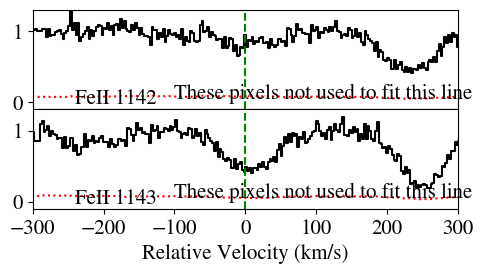

[[np.float64(1142.3656)], [np.float64(15.316)], [np.float64(29.33)], [np.float64(0.00089)], [np.float64(3.504)], [np.float64(-82.39230000003401)], [np.float64(89.40029999999062)]]
[[np.float64(1143.226)], [np.float64(15.316)], [np.float64(29.33)], [np.float64(0.00089)], [np.float64(3.504)], [np.float64(-81.72330000002054)], [np.float64(88.73129999995561)]]


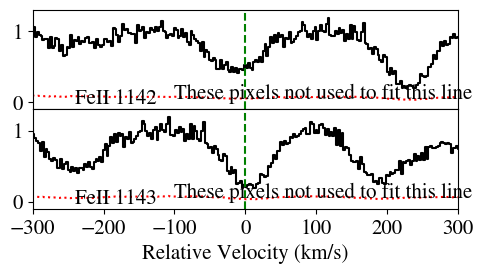

[[np.float64(1250.578)], [np.float64(15.94)], [np.float64(29.848)], [np.float64(0.00092)], [np.float64(-4.068)], [np.float64(-111.29090000003322)], [np.float64(103.15489999999487)]]
[[np.float64(1253.805)], [np.float64(15.94)], [np.float64(29.848)], [np.float64(0.00092)], [np.float64(-4.068)], [np.float64(-111.01990000002236)], [np.float64(102.88390000005106)]]


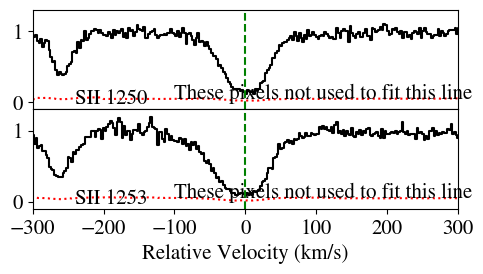

[]

In [38]:
plot_fit_lines_from_parfile('/Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/BAT99 114/G130M_1291_LP5_2072.416_16812/lf2t2c010/modified_component_groups/input_group_0.VP')

In [20]:
inspect_fits('/Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/BAT99 114/G130M_1291_LP5_2072.416_16812/lf2t2c010/modified_component_groups/input_group_0.VP')

Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
Bad METADATA;  proceeding without


AttributeError: 'list' object has no attribute 'wavelength'